In [31]:
################################################
# Name: LI Yuntong
# STID: 20944800
# ITSC E-mail: ylino@connect.ust.hk
################################################

If you have any questions:
* Please inquire via email (with title **COMP4421 Inquiry: ...)**
* Yin Lai Lyndon Chan (yllchan@connect.ust.hk)


# **Overview**

In this assignment, you need to complete a series of programming tasks designed to enhance your understanding of segmentation, registration, and compression.

# **IMPORTANT**

*   Necessary libraries have already been imported for you. You are **NOT allowed** to import and use any other libraries. You may try to request for approval if you think any external libraries are neccessary. Otherwise, zero mark will be directly assigned and no appealing is allowed.

*   You are required to implement the code block in the designated area **OR** indicated by **TODO**. Any responses or modifications outside of this area will result in zero mark, and no appealing is allowed. (**Designated area** is the area between "start of the code" ... "end of the code")

*   **Please read instructions and comments of the skeleton carefully before writing you own codes.**

*   Since this assignment could be more complicated and challenging, we didn't provide you dummy code or variables in most of tasks. Please create them by yourself to fit the expected output.  


# **Submission**
*   Your final submission must include:
The programming3.ipynb with your implemented algorithm.
The results directory with all the result images. **Package everything of your assignment into a .zip file named [YourName]_COMP4421_Assignment3.zip and submit it via Canvas.**  

*   Your submitted .ipynb must contain the final results when you run the code. I.e., do not clear output when submit the assignments.  


# **Deadline**

*   All submissions must be made via the course repository by 11:55 PM on May 10, 2026.  

*   Late assignments will incur a 10 scores penalty.

*   Assignment submissions with more than one day will not be accepted.

# **Grading Criteria**
Your assignment will be graded on the following factors:
*   The correctness and efficiency of the implemented algorithm.
*   The clarity and quality of the result images.
*   The organization and documentation of the result images.
*   The adherence to the assignment requirements and submission guidelines.


# Assignment 3

## Mount to the Google Drive

**IMPORTANT**:  
*   Make sure you mount the drive properly and upload all neccessary images before starting the assignment.

*   If you are writing code on local envoirnment instead of using Colab, you do not need to execute this block.  

*   You may refers to the [reference](https://saturncloud.io/blog/how-to-import-files-from-google-drive-to-colab/) or related tutorials.

In [32]:
from google.colab import drive
import os

drive.mount('/content/drive')

# TODO:
# Define the path for your working directory
new_working_directory = '/content/drive/MyDrive/COMP4421_Assignment3'

# Change the current working directory to the new path
os.chdir(new_working_directory)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Library

In [33]:
import cv2
import math
from math import sqrt, cos, acos, degrees, radians, pi
import numpy as np
from google.colab.patches import cv2_imshow

from PIL import Image, ImageFilter, ImageOps
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.signal import argrelextrema

import random
from tqdm.notebook import tqdm

## **Question 1**: EM thresholding for image segmentation

In this question, you will implement **Expectation-Maximization (EM) thresholding** to segment an image. While the original input is in the RGB color space, we have already performed the conversion to the **HSI (Hue, Saturation, Intensity)** space for you—similar to the methodology used in Assignment 2.

### 3.1 Task Overview
Your primary objective is to operate on the **Intensity ($I$) channel** to perform the segmentation. Because the Intensity channel decouples the brightness information from color, it serves as the ideal data source for statistical thresholding algorithms.

### 3.2 Instructions
* **Pre-processing:** We have provided the necessary pre-processing steps in the code block below. You do **not** need to apply further filters or adjustments to the input.
* **Execution:** Implement your EM algorithm and begin the segmentation directly on the processed intensity data.
* **Analysis:** After obtaining your segmentation results, you will be required to answer several subsequent questions.

Please read the instructions and follow our steps to implement the algorithm. Then fill in your codes and answers in the designated area.

In [34]:
# source: https://github.com/SVLaursen/Python-RGB-to-HSI/blob/master/converter.py
# DO NOT modify these codes
def RGB_TO_HSI(img):
    with np.errstate(divide='ignore', invalid='ignore'):

        #Load image with 32 bit floats as variable type
        bgr = np.float64(img)/255

        #Separate color channels
        blue = bgr[:,:,0]
        green = bgr[:,:,1]
        red = bgr[:,:,2]

        #Calculate Intensity
        def calc_intensity(red, blue, green):
            return np.divide(blue + green + red, 3)

        #Calculate Saturation
        def calc_saturation(red, blue, green):
            minimum = np.minimum(np.minimum(red, green), blue)
            saturation = 1 - (3 / (red + green + blue + 0.001) * minimum)

            return saturation

        #Calculate Hue
        def calc_hue(red, blue, green):
            hue = np.copy(red)

            for i in range(0, blue.shape[0]):
                for j in range(0, blue.shape[1]):
                    hue[i][j] = 0.5 * ((red[i][j] - green[i][j]) + (red[i][j] - blue[i][j])) / \
                                math.sqrt((red[i][j] - green[i][j])**2 +
                                        ((red[i][j] - blue[i][j]) * (green[i][j] - blue[i][j])))
                    hue[i][j] = math.acos(hue[i][j])

                    if blue[i][j] <= green[i][j]:
                        hue[i][j] = hue[i][j]
                    else:
                        hue[i][j] = ((360 * math.pi) / 180.0) - hue[i][j]

            return hue

        #Merge channels into picture and return image
        hsi = cv2.merge((calc_hue(red, blue, green), calc_saturation(red, blue, green), calc_intensity(red, blue, green)))
        return hsi

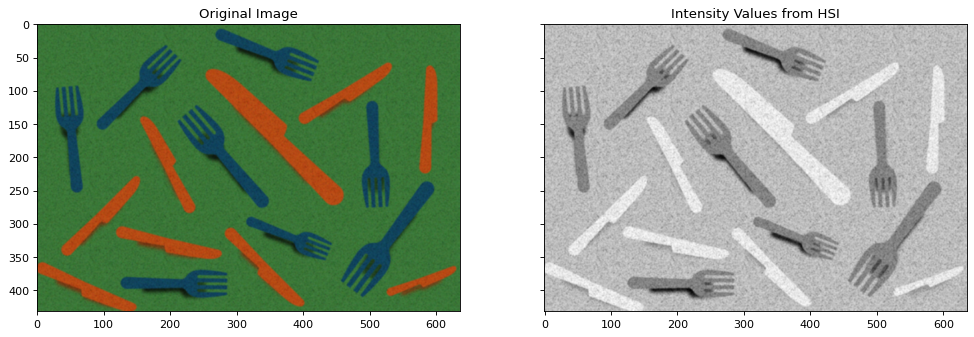

In [35]:
################################################
# Do NOT modify codes in this block.           #
################################################
img = cv2.imread('./img/input_img.png', 1)
img = cv2.GaussianBlur(img, (3, 3), 0)
blur = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# RGB to HSI has already been provided for you
hsi_img = RGB_TO_HSI(blur)
h, s, i = cv2.split(hsi_img)


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 15), dpi=80, sharex=True, sharey=True)
ax[0].imshow(blur)
ax[1].imshow(i, 'gray')

ax[0].title.set_text('Original Image')
ax[1].title.set_text('Intensity Values from HSI')

As you could observe in the input image, the scene consists of three distinct luminance levels (several foreground objects (forks and knives) against a background). For this task, we assume that the pixel intensities follow a **mixture of three Gaussian distributions**, where each distribution corresponds to a specific functional component of the image:

1. **The Forks:** Represented by the lower intensity (darker) peaks.
2. **The Background:** Represented by the mid-tone intensity values.
3. **The Knives:** Represented by the higher intensity (brightest) peaks.

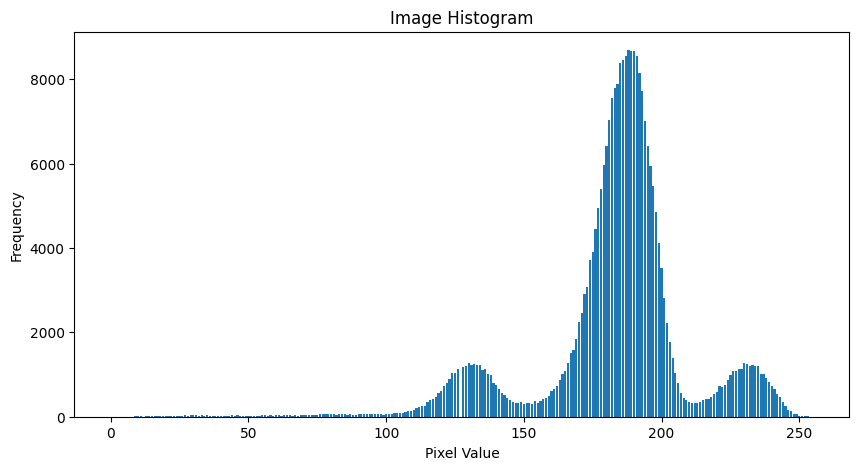

In [36]:
################################################
# Do NOT modify codes in this block.           #
################################################
gray = (((i-np.min(i))/(np.max(i)-np.min(i)))*255).astype(np.uint8)
pil_image = Image.fromarray(gray)

# Calculate histogram
histogram = pil_image.histogram()

# Plot histogram using matplotlib
plt.figure(figsize=(10, 5))
plt.bar(range(256), histogram)
plt.title('Image Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

In this section, you will implement EM algorithm to estimate the mean, variance, and weights of three Gaussian distribution. We have prepared a gaussian function for you. Then, you need to complete the following parts:

1. initialize parameters (mean, variance, and weights). To initialize mean values, in this assignment, please first find the valley of the intensity histogram (around 150 and 210 as we could observe). Then take the average values of three regions as the initial mean, as shown in the figure below. For example, initial mu_1 is (150+0)/2.

 **NOTE 1**: You NEED to find your own approach to estimate these two values, and then calculate three means. Do not hardcode numerical results by inputting constants like 0 or 150 directly.

 **NOTE 2**: The intensity distribution is not ideally smooth. It is normal that different implementations produces different results.

2. E- and M-steps to estimate mean, variance, and weights.

3. conduct E- and M-steps iteratively in em_algorithm() for 300 iterations. You may decide number of iterations here by yourself.



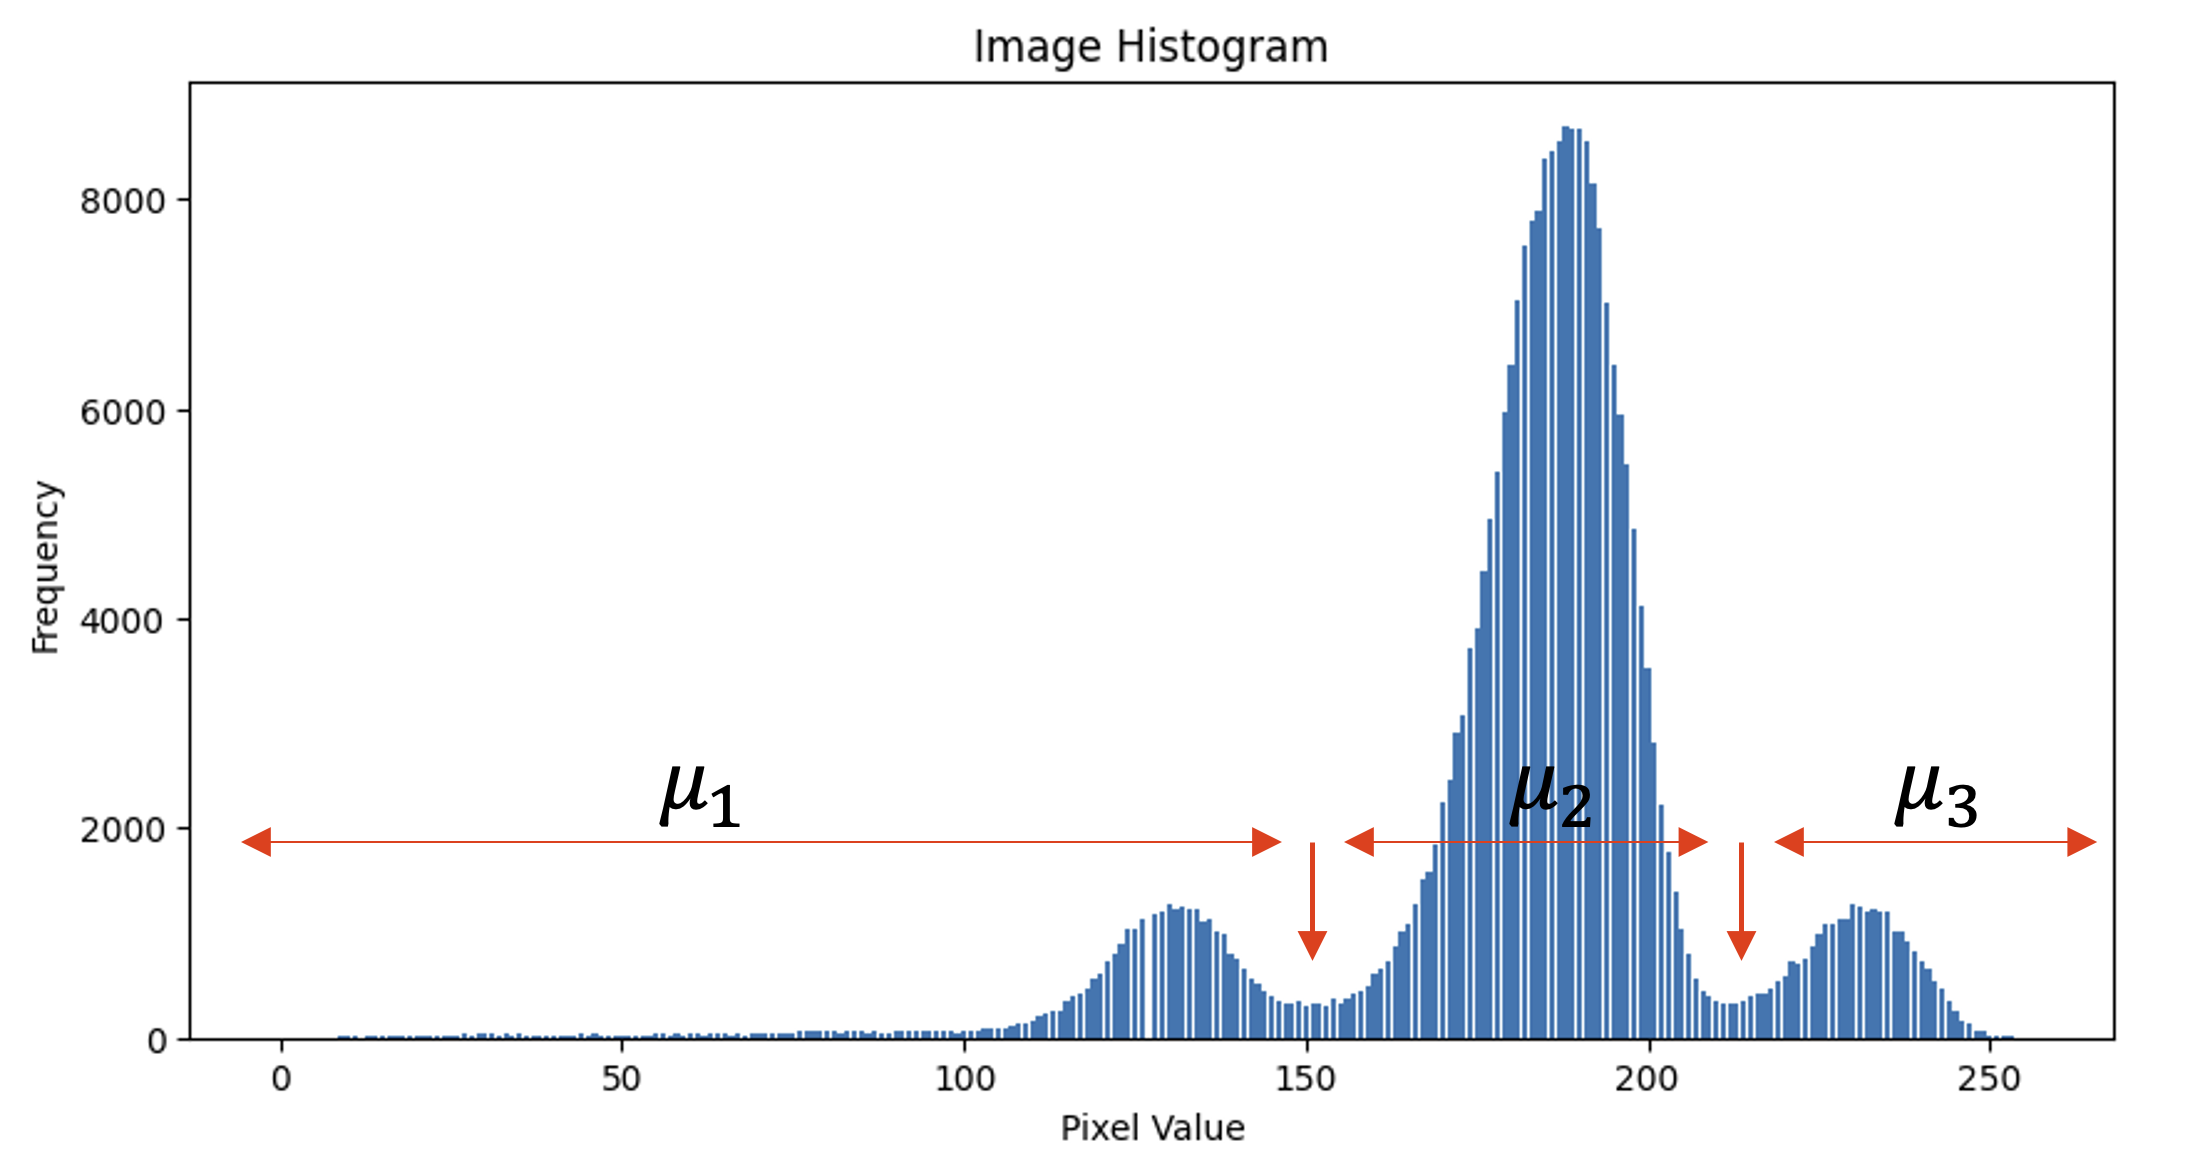

In [37]:
def gaussian(x, mean, std_dev):
    # Calculates the probability density of x for a given normal distribution.
    return np.exp(-np.square(x - mean) / (2 * std_dev**2)) / (np.sqrt(2 * np.pi) * std_dev)

def initialize_means(histogram, order):
    """
    Finds initial mean values by smoothing the histogram and locating valleys.
    The order parameter controls the sensitivity of local minima detection.
    """
    # Start of the code
    hist = np.asarray(histogram, dtype=np.float64)
    bins = np.arange(len(hist))
    window_size = 2 * order + 1
    kernel = np.ones(window_size) / window_size
    smoothed_hist = np.convolve(hist, kernel, mode='same')

    # Find indices of relative maxima using argrelextrema
    valleys = argrelextrema(smoothed_hist, np.less, order=order)[0]
    nonzero_bins = bins[hist > 0]
    lower = nonzero_bins[0] + int(0.2 * (nonzero_bins[-1] - nonzero_bins[0]))
    upper = nonzero_bins[-1] - int(0.05 * (nonzero_bins[-1] - nonzero_bins[0]))
    valleys = valleys[(valleys > lower) & (valleys < upper)]
    if len(valleys) < 2:
        valleys = np.percentile(nonzero_bins, [33, 66]).astype(int)
    else:
        valleys = np.sort(valleys[np.argsort(smoothed_hist[valleys])[:2]])

    split_points = np.concatenate(([nonzero_bins[0]], valleys[:2], [nonzero_bins[-1]]))
    means = np.array([(split_points[i] + split_points[i + 1]) / 2 for i in range(3)], dtype=np.float64)
    # End of the code

    return means


def initialize_parameters(data, num_components):
    """Initializes the three Gaussian parameters: means, variances, and mixing weights."""
    # Start of the code
    histogram = np.bincount(data.astype(np.uint8), minlength=256)
    means = initialize_means(histogram, order=10)
    boundaries = np.concatenate(([-np.inf], (means[:-1] + means[1:]) / 2, [np.inf]))
    variances = np.zeros(num_components, dtype=np.float64)
    weights = np.zeros(num_components, dtype=np.float64)
    for i in range(num_components):
        region = data[(data >= boundaries[i]) & (data < boundaries[i + 1])]
        if len(region) == 0:
            variances[i] = np.var(data)
            weights[i] = 1 / num_components
        else:
            variances[i] = max(np.var(region), 1e-6)
            weights[i] = len(region) / len(data)
    # End of the code
    return means, variances, weights

def e_step(data, means, variances, weights, num_components):
    """
    Expectation Step: Evaluates the posterior probability (responsibility)
    that each pixel belongs to each Gaussian component.
    """
    # Start of the code
    responsibilities = np.zeros((len(data), num_components), dtype=np.float64)
    for i in range(num_components): # Feel free to modify or replace this code
        responsibilities[:, i] = weights[i] * gaussian(data, means[i], np.sqrt(variances[i]))
    total = np.sum(responsibilities, axis=1, keepdims=True)
    total[total == 0] = 1e-12
    responsibilities = responsibilities / total
    # End of the code
    return responsibilities

def m_step(data, responsibilities, num_components):
    """
    Maximization Step: Re-estimates means, variances, and weights
    by maximizing the likelihood found in the E-step.
    """
    # Start of the code
    means = np.zeros(num_components, dtype=np.float64)
    variances = np.zeros(num_components, dtype=np.float64)
    weights = np.zeros(num_components, dtype=np.float64)
    for i in range(num_components): # Feel free to modify or replace this code
        responsibility_sum = np.sum(responsibilities[:, i])
        means[i] = np.sum(responsibilities[:, i] * data) / responsibility_sum
        variances[i] = np.sum(responsibilities[:, i] * np.square(data - means[i])) / responsibility_sum
        variances[i] = max(variances[i], 1e-6)
        weights[i] = responsibility_sum / len(data)
    order = np.argsort(means)
    means = means[order]
    variances = variances[order]
    weights = weights[order]
    # End of the code
    return means, variances, weights


def em_algorithm(data, num_components=3, num_iterations=100):
    means, variances, weights = initialize_parameters(data, num_components)
    for _ in range(num_iterations):
        '''
        TODO: Please finish above E- and M-step functions, and apply EM for
        'num_iterations' iterations, and produces three arrays of mean, variance,
        and weights.
        '''
        # Start of the code
        responsibilities = e_step(data, means, variances, weights, num_components)
        means, variances, weights = m_step(data, responsibilities, num_components)
        # End of the code
    return means, variances, weights

means, variances, weights = em_algorithm(gray.ravel(), num_iterations=300)
print(f'estimated results \nmeans: {means} \nvariances: {variances} \nweights: {weights}')

estimated results 
means: [145.11296987 187.02118576 230.70041702] 
variances: [1102.16990709   81.12775661   60.00508805] 
weights: [0.19454738 0.71415723 0.09129539]


In this section, after estimating your Gaussian parameters, you are required to calculate two thresholds ($T_1$ and $T_2$) to segment the image.

**Task:**
Find the intersection points between the three distributions:
* **$T_1$:** Intersection between the **Forks** and the **Background**.
* **$T_2$:** Intersection between the **Background** and the **Knives**.

Please refer to the lecture notes for calculation. You could calculate T1 and T2 by writing the formula **explicitly**.

Alternatively, you are encouraged to use fsolve(). This tool finds the roots of a function (where the difference between two Gaussians is zero).
   * Refer to the [fsolve — SciPy v1.17.0 Manual](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fsolve.html) for implementation details.

**Note:** The template functions provided below are optional. If you choose to calculate them explicitly, feel free to modify or remove them. **Do not hardcode numerical results**; thresholds must be derived from your estimated EM parameters.

In [38]:
# Start of the code
# Note: Defining these functions is only required if you choose to use fsolve().
# You may modify or skip this structure if you prefer writing the formula explicitly.
def function_t1(x):
    x = np.asarray(x)
    return weights[0] * gaussian(x, means[0], np.sqrt(variances[0])) - weights[1] * gaussian(x, means[1], np.sqrt(variances[1]))

def function_t2(x):
    x = np.asarray(x)
    return weights[1] * gaussian(x, means[1], np.sqrt(variances[1])) - weights[2] * gaussian(x, means[2], np.sqrt(variances[2]))
# Hint: Provide a starting guess for the thresholds if you are using fsolve.
T1 = float(fsolve(function_t1, (means[0] + means[1]) / 2)[0])
T2 = float(fsolve(function_t2, (means[1] + means[2]) / 2)[0])
# End of the code
print(T1, T2)

165.7160224892919 213.582101138147


By apply above threshold, we could segment the image into three classes. Here we plot them in separated masks. Each mask represents a class of objects, i.e., forks, backgrounds, and knives.

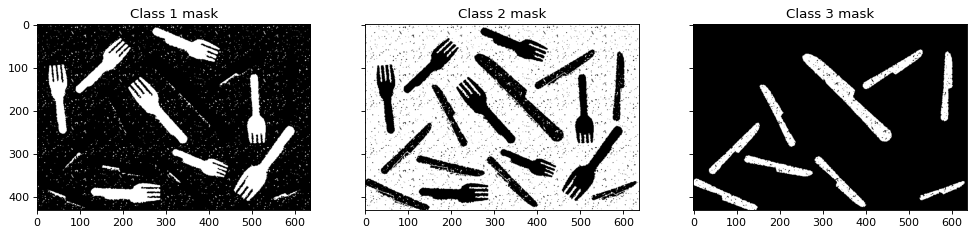

In [39]:
################################################
# Do NOT modify codes in this block.           #
################################################
# Set the threshold value
threshold_1 = T1 if T1 < T2 else T2
threshold_2 = T2 if T1 < T2 else T1

mask1 = cv2.inRange(gray, 0, threshold_1)
mask2 = cv2.inRange(gray, threshold_1+1, threshold_2)
mask3 = cv2.inRange(gray, threshold_2+1, 255)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 20), dpi=80, sharex=True, sharey=True)
ax[0].imshow(mask1, 'gray')
ax[1].imshow(mask2, 'gray')
ax[2].imshow(mask3, 'gray')
ax[0].title.set_text('Class 1 mask')
ax[1].title.set_text('Class 2 mask')
ax[2].title.set_text('Class 3 mask')

## **Question 2**: SIFT and RANSAC for Image Stitching

In this question, you need to use the SIFT algorithm to detect and describe local features in the images, and then apply the RANSAC algorithm to robustly match these features and compute the homography between the images.

Hint & Note:
*   In this assignment **you are allowed to use SIFT and BFMatch built in function in Opencv**. For SIFT algorithm you can refer to [Opencv Document for SIFT](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html). For Brute-Force Matcher algorithm you can refer to [Opencv Document for Brute-Force Matcher](https://docs.opencv.org/3.4/dc/dc3/tutorial_py_matcher.html).

*   Use gray scale image for SIFT algorithm may have a better result.

*   The BFMatcher function provided by Opencv takes into account the situation of processing **different numbers of key points**. When iterating through each descriptor in the smaller descriptor set and looks for the best match in the larger descriptor set.


In [40]:
left_gray = cv2.imread('./img/left.png', cv2.IMREAD_GRAYSCALE)
left_rgb = cv2.imread('./img/left.png')
left_rgb = cv2.cvtColor(left_rgb, cv2.COLOR_BGR2RGB)
right_gray = cv2.imread('./img/right.png', cv2.IMREAD_GRAYSCALE)
right_rgb = cv2.imread('./img/right.png')
right_rgb = cv2.cvtColor(right_rgb, cv2.COLOR_BGR2RGB)

height, width = left_gray.shape[0], left_gray.shape[1]
right_gray = cv2.resize(right_gray, (width, height))

height, width = left_rgb.shape[0], left_rgb.shape[1]
right_rgb = cv2.resize(right_rgb, (width, height))

In [41]:
'''
TODO:
1. Use SIFT get keypoints and descriptors for the left and right image
2. Draw keypoints in the original image and concatenate two images as a whole image
'''
# Start of the code
sift = cv2.SIFT_create()
kp_left, des_left = sift.detectAndCompute(left_gray, None)
kp_right, des_right = sift.detectAndCompute(right_gray, None)

kp_left_img = cv2.drawKeypoints(left_rgb, kp_left, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)


kp_right_img = cv2.drawKeypoints(right_rgb, kp_right, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
# End of the code

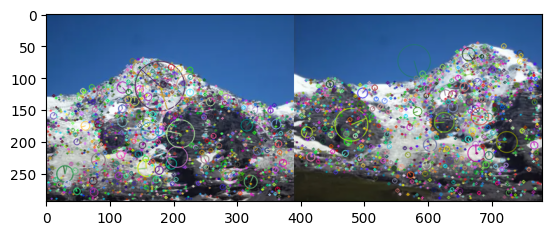

In [42]:
################################################
# IMPORTANT:                                   #
# Do NOT modify codes in this block.           #
# DO NOT write any codes/functions OUTSIDE of  #
# the given area.                              #
################################################

total_kp = np.concatenate((kp_left_img, kp_right_img), axis=1)
plt.imshow(total_kp)

In [43]:
'''
TODO:
1. Use BFMatch with SIFT Descriptors
2. Apply ratio test to return the best k match
'''
def matcher(kp1, des1, img1, kp2, des2, img2, k):
    # Start of the code
    bf = cv2.BFMatcher()
    raw_matches = bf.knnMatch(des1, des2, k=k)
    good_matches = []
    # BFMatcher with default params


    # Apply ratio test
    for match_group in raw_matches:
        if len(match_group) < 2:
            continue
        m, n = match_group[0], match_group[1]
        if m.distance < 0.75 * n.distance:
            x1, y1 = kp1[m.queryIdx].pt
            x2, y2 = kp2[m.trainIdx].pt
            good_matches.append((m.distance, [x1, y1, x2, y2]))
    good_matches = sorted(good_matches, key=lambda item: item[0])
    matches = np.array([coords for _, coords in good_matches], dtype=np.float64)

    # End of the code
    return matches

In [44]:
def plot_matches(matches, total_img):
    match_img = total_img.copy()
    offset = total_img.shape[1]/2
    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    ax.imshow(match_img)

    ax.plot(matches[:, 0], matches[:, 1], 'xr')
    ax.plot(matches[:, 2] + offset, matches[:, 3], 'xr')

    ax.plot([matches[:, 0], matches[:, 2] + offset], [matches[:, 1], matches[:, 3]],
              'r', linewidth=0.5)

    plt.show()

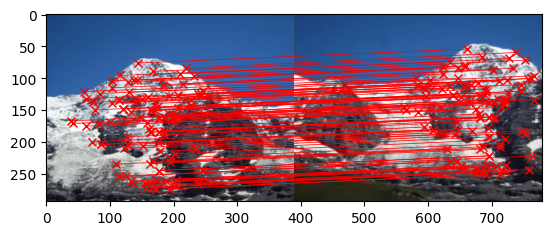

In [45]:
################################################
# IMPORTANT:                                   #
# Do NOT modify codes in this block.           #
# DO NOT write any codes/functions OUTSIDE of  #
# the given area.                              #
################################################

# k is the number of best matches
k = 2
matches = matcher(kp_left, des_left, left_rgb, kp_right, des_right, right_rgb, k)

total_img = np.concatenate((left_rgb, right_rgb), axis=1)
# just plot 100 points
plot_matches(matches[:100], total_img)

In real-world computer vision tasks, such as stitching panoramas or aligning medical scans, we begin by identifying matching points between two images. However, feature matching is rarely perfect. You will inevitably encounter **outliers**—matches that are mathematically incorrect due to motion blur, occlusions, or repetitive textures.

If we use a standard "Least Squares" approach on all matches, even a single outlier can significantly distort the estimated transformation. To solve this, we use **RANSAC (Random Sample Consensus)**.

### The Homography Matrix
A **Homography** is a $3 \times 3$ transformation matrix that relates coordinates of points in one image to coordinates in another, provided the scene is planar or the camera is rotating around its center.

The matrix $H$ is structured as:
$$H = \begin{bmatrix}
h_{11} & h_{12} & h_{13} \\
h_{21} & h_{22} & h_{23} \\
h_{31} & h_{32} & h_{33}
\end{bmatrix}$$

It encodes rotation, translation, scaling, and perspective transformations.

In this section, you will utilize the provided helper functions to implement the RANSAC loop.

### Provided Utility Functions

* `homography(pairs)`: Computes the candidate matrix $H$ using Singular Value Decomposition (SVD).
* `random_point(matches, k=4)`: Randomly samples the minimum subset (4 pairs) required to hypothesize a Homography.
* `compute_error(points, H)`: Calculates the **Reprojection Error**—the squared distance between the ground-truth coordinates and the coordinates projected by your estimated $H$.

In [46]:
def homography(pairs):
    rows = []
    for i in range(pairs.shape[0]):
        p1 = np.append(pairs[i][0:2], 1)
        p2 = np.append(pairs[i][2:4], 1)
        row1 = [0, 0, 0, p1[0], p1[1], p1[2], -p2[1]*p1[0], -p2[1]*p1[1], -p2[1]*p1[2]]
        row2 = [p1[0], p1[1], p1[2], 0, 0, 0, -p2[0]*p1[0], -p2[0]*p1[1], -p2[0]*p1[2]]
        rows.append(row1)
        rows.append(row2)
    rows = np.array(rows)
    U, s, V = np.linalg.svd(rows)
    H = V[-1].reshape(3, 3)
    H = H/H[2, 2] # standardize to let w*H[2,2] = 1
    return H

In [47]:
def random_point(matches, k=4):
    idx = random.sample(range(len(matches)), k)
    point = [matches[i] for i in idx ]
    return np.array(point)

In [48]:
def compute_error(points, H):
    # compute_error function to calculates the reprojection error of points transformed by a homography matrix H
    num_points = len(points)
    all_p1 = np.concatenate((points[:, 0:2], np.ones((num_points, 1))), axis=1)
    all_p2 = points[:, 2:4]
    estimate_p2 = np.zeros((num_points, 2))
    for i in range(num_points):
        temp = np.dot(H, all_p1[i])
        estimate_p2[i] = (temp/temp[2])[0:2]

    errors = np.linalg.norm(all_p2 - estimate_p2 , axis=1) ** 2

    return errors

In [49]:
'''
TODO:
Implement RANSAC algorithm

Hint:
you can use the function(homography, random_point, compute_error) we provide to implement RANSAC algorithm or write the whole algorithm by yourselves.
'''
def ransac(matches, threshold, iters):
    num_best_inliers = 0

    # Start of the code
    best_inliers = np.empty((0, matches.shape[1]))
    best_H = np.eye(3)
    for _ in range(iters):
        sample = random_point(matches, 4)
        try:
            H = homography(sample)
            errors = compute_error(matches, H)
        except np.linalg.LinAlgError:
            continue
        inliers = matches[errors < threshold]
        if len(inliers) > num_best_inliers:
            num_best_inliers = len(inliers)
            best_inliers = inliers
            best_H = H
    if len(best_inliers) >= 4:
        best_H = homography(best_inliers)

    # End of the code
    print("inliers/matches: {}/{}".format(num_best_inliers, len(matches)))
    return best_inliers, best_H

inliers/matches: 565/606


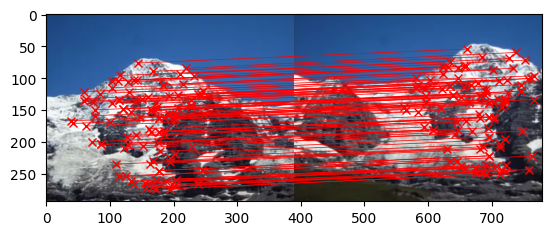

In [50]:
################################################
# IMPORTANT:                                   #
# Do NOT modify codes in this block.           #
# DO NOT write any codes/functions OUTSIDE of  #
# the given area.                              #
# The output can be slightly different (+-1/2) #
################################################

inliers, H = ransac(matches, 0.5, 2000)
# show inliers matches
plot_matches(inliers[:100], total_img)

In [51]:
def stitch_img(left, right, H):
    # Convert to double and normalize. Avoid noise.
    left = cv2.normalize(left.astype('float'), None,
                            0.0, 1.0, cv2.NORM_MINMAX)

    # Convert to double and normalize.
    right = cv2.normalize(right.astype('float'), None,
                            0.0, 1.0, cv2.NORM_MINMAX)

    # left image
    height_l, width_l, channel_l = left.shape
    corners = [[0, 0, 1], [width_l, 0, 1], [width_l, height_l, 1], [0, height_l, 1]]
    corners_new = [np.dot(H, corner) for corner in corners]
    corners_new = np.array(corners_new).T
    x_news = corners_new[0] / corners_new[2]
    y_news = corners_new[1] / corners_new[2]
    y_min = min(y_news)
    x_min = min(x_news)

    translation_mat = np.array([[1, 0, -x_min], [0, 1, -y_min], [0, 0, 1]])
    H = np.dot(translation_mat, H)

    # Get height, width
    height_new = int(round(abs(y_min) + height_l))
    width_new = int(round(abs(x_min) + width_l))
    size = (width_new, height_new)

    # right image
    warped_l = cv2.warpPerspective(src=left, M=H, dsize=size)

    height_r, width_r, channel_r = right.shape

    height_new = int(round(abs(y_min) + height_r))
    width_new = int(round(abs(x_min) + width_r))
    size = (width_new, height_new)


    warped_r = cv2.warpPerspective(src=right, M=translation_mat, dsize=size)

    black = np.zeros(3)  # Black pixel.

    # Stitching procedure, store results in warped_l.
    for i in tqdm(range(warped_r.shape[0])):
        for j in range(warped_r.shape[1]):
            pixel_l = warped_l[i, j, :]
            pixel_r = warped_r[i, j, :]

            if not np.array_equal(pixel_l, black) and np.array_equal(pixel_r, black):
                warped_l[i, j, :] = pixel_l
            elif np.array_equal(pixel_l, black) and not np.array_equal(pixel_r, black):
                warped_l[i, j, :] = pixel_r
            elif not np.array_equal(pixel_l, black) and not np.array_equal(pixel_r, black):
                warped_l[i, j, :] = (pixel_l + pixel_r) / 2
            else:
                pass

    stitch_image = warped_l[:warped_r.shape[0], :warped_r.shape[1], :]
    return stitch_image

  0%|          | 0/332 [00:00<?, ?it/s]

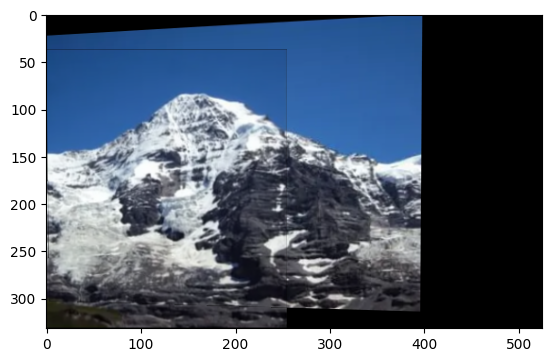

In [52]:
plt.imshow(stitch_img(left_rgb, right_rgb, H))

## **Question 3**: JPEG Compression  
In this question, you will implement the core stages of the JPEG compression pipeline. To assist you, we have already provided the ziazag, quant matrix, and the Run-Length Encoding (RLE) function. Meanwhile, please be noted that, in this assignment, for all coefficients, we use running length coding to handle them for simplicity.

Your Task:

You are responsible for implementing the zig-zag, DCT and quantization in this question.

In [53]:
zigzag_index = np.array([
            0, 1, 8, 16, 9, 2, 3, 10,
            17, 24, 32, 25, 18, 11, 4, 5,
            12, 19, 26, 33, 40, 48, 41, 34,
            27, 20, 13, 6, 7, 14, 21, 28,
            35, 42, 49, 56, 57, 50, 43, 36,
            29, 22, 15, 23, 30, 37, 44, 51,
            58, 59, 52, 45, 38, 31, 39, 46,
            53, 60, 61, 54, 47, 55, 62, 63
        ])

quant_matrix = np.array([[16, 11, 10, 16, 24, 40, 51, 61],
                  [12, 12, 14, 19, 26, 58, 60, 55],
                  [14, 13, 16, 24, 40, 57, 69, 56],
                  [14, 17, 22, 29, 51, 87, 80, 62],
                  [18, 22, 37, 56, 68, 109, 103, 77],
                  [24, 35, 55, 64, 81, 104, 113, 92],
                  [49, 64, 78, 87, 103, 121, 120, 101],
                  [72, 92, 95, 98, 112, 100, 103, 99]])

In [54]:
# Please traverse the image to zig-zag coefficients in this function
def zigzag(blocks):
        # Start of the code
        output = []
        for block in blocks:
                output.extend(np.asarray(block).reshape(-1)[zigzag_index].tolist())
        # End of the code
        return output

In [55]:
def rle(message):
    """
    Performs Run-Length Encoding (RLE) to compress the quantized DCT coefficients.

    This function reduces data size by replacing consecutive identical values
    (specifically zeros) with a count and the value itself. This is highly effective
    after the zigzag scan, which groups high-frequency zeros at the end of the block.
    """
    encoded_message = []
    i = 0

    while (i <= len(message)-1):
        count = 1
        ch = message[i]
        j = i
        while (j < len(message)-1):
            if (message[j] == message[j+1]):
                count = count+1
                j = j+1
            else:
                break
        if ch==0:
            encoded_message.append(count)
            encoded_message.append(ch)
        else:
            encoded_message.append(ch)
        i = j+1
    return encoded_message

In [56]:
# Load the image
image = cv2.imread('./img/cameraman.png', 0)

# Split the image into 8x8 blocks
for i in range(0, image.shape[1], 8):
    for j in range(0, image.shape[0], 8):
        blocks = [image[j:j+8, i:i+8]]

# Apply DCT and Quantization
# Hint: you are allowed to use cv2.dct to conduct transformation directly
quantized_blocks = []
for block in blocks:
    # Start of the code

    # DCT
    dct_block = cv2.dct(block.astype(np.float32) - 128)
    # Quantization
    quantized_block = (dct_block / quant_matrix).astype(int)
    quantized_blocks.append(quantized_block)

    # End of the code

This block could help checking your output. You may compare it with our expected output.

In [57]:
# --- Validation Block ---
# This section checks if your DCT and Quantization logic is mathematically correct.
# By performing Zigzag scanning and Run-Length Encoding (RLE), we measure how
# effectively your code compressed the 8x8 blocks.

out = rle(zigzag(quantized_blocks))

# We convert the length of the compressed data into a 2-byte 'big-endian' format.
# If your math is correct, this 'fingerprint' should match our expected output.
final = ((len(out)).to_bytes(2, byteorder='big'))

print(final)

# Expected output: b'\x00\x10'

b'\x00\x10'
